**GNN Analysis - node normalisation, performance evaluation**

In [118]:
# import required libraries
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

**Step-1: Create Graph**

In [ ]:
graph = nx.Graph() # create an empty graph

# define edges
edges = [
    ("A", "B"), ("A", "C"), ("B", "D"), ("C", "E"),
    ("D", "F"), ("E", "G"), ("F", "H"), ("G", "H"),
    ("A", "D"), ("B", "E"), ("C", "F"), ("D", "G"), ("E", "H")
]

# add edges to the graph
graph.add_edges_from(edges)

print(graph)
print(graph.edges())

Graph with 8 nodes and 13 edges
[('A', 'B'), ('A', 'C'), ('A', 'D'), ('B', 'D'), ('B', 'E'), ('C', 'E'), ('C', 'F'), ('D', 'F'), ('D', 'G'), ('E', 'G'), ('E', 'H'), ('F', 'H'), ('G', 'H')]


**Step-2: Add additional features with structure**

In [120]:
graph.nodes()

NodeView(('A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'))

In [121]:
node_list = list(graph.nodes)
features = {}

# assign features to nodes
# nodes A-D are of class 0 and centered around 0.3 and nodes E-H are of class 1 and centered around 0.7
for i, node in enumerate(node_list):
    if i < len(node_list) / 2:
        features[node] = np.random.normal(0.3, 0.05, 4)  
    else:
        features[node] = np.random.normal(0.7, 0.05, 4)  
    graph.nodes[node]['feature'] = features[node]

node_features = torch.tensor([graph.nodes[node]['feature'] for node in graph.nodes], dtype=torch.float32)
print("Node Features:\n", node_features)

Node Features:
 tensor([[0.3853, 0.2467, 0.3431, 0.3655],
        [0.2724, 0.3598, 0.2870, 0.3703],
        [0.2511, 0.2830, 0.2961, 0.2618],
        [0.3204, 0.2721, 0.3786, 0.4283],
        [0.6331, 0.6977, 0.6622, 0.6336],
        [0.7438, 0.7201, 0.7319, 0.7436],
        [0.6399, 0.7201, 0.6914, 0.7131],
        [0.7647, 0.7850, 0.6947, 0.7659]])


In [122]:
# assign random binary labels
labels = torch.tensor([0,0,0,0,1,1,1,1], dtype=torch.long)  # structured labels
print("Labels:", labels)

Labels: tensor([0, 0, 0, 0, 1, 1, 1, 1])


**Adjacency matrix normalisation**

In [ ]:
# create adjacency matrix
adj_matrix = nx.to_numpy_array(graph)

# normalize adjacency matrix
adj_matrix += np.eye(adj_matrix.shape[0])  # Add self-loops
deg = np.sum(adj_matrix, axis=1)

# Compute D^(-1/2) 
D_inv_sqrt = np.diag(1.0 / np.sqrt(deg))
adj_matrix = D_inv_sqrt @ adj_matrix @ D_inv_sqrt
adj_matrix = torch.tensor(adj_matrix, dtype=torch.float32)

print("Adjacency Matrix:\n", adj_matrix)

Adjacency Matrix:
 tensor([[0.2500, 0.2500, 0.2500, 0.2236, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.0000, 0.2236, 0.2236, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.0000, 0.2500, 0.0000, 0.2236, 0.2500, 0.0000, 0.0000],
        [0.2236, 0.2236, 0.0000, 0.2000, 0.0000, 0.2236, 0.2236, 0.0000],
        [0.0000, 0.2236, 0.2236, 0.0000, 0.2000, 0.0000, 0.2236, 0.2236],
        [0.0000, 0.0000, 0.2500, 0.2236, 0.0000, 0.2500, 0.0000, 0.2500],
        [0.0000, 0.0000, 0.0000, 0.2236, 0.2236, 0.0000, 0.2500, 0.2500],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.2236, 0.2500, 0.2500, 0.2500]])


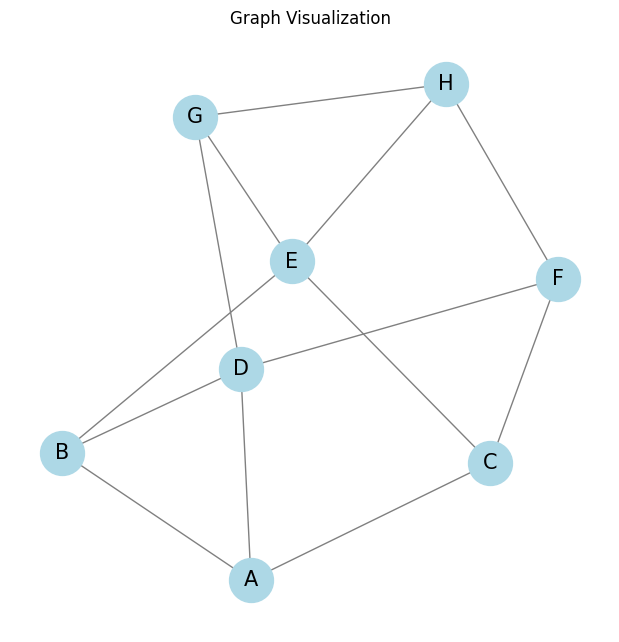

In [124]:
# visualize the graph
plt.figure(figsize=(6, 6))
pos = nx.spring_layout(graph)
nx.draw(graph, pos, with_labels=True, node_color="lightblue", edge_color="gray", node_size=1000, font_size=15)
plt.title("Graph Visualization")
plt.show()

**Step-3: Enhanced GNN model**

In [ ]:
class SimpleGNN(nn.Module):
    ''' A simple Graph Neural Network with 3 layers'''
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SimpleGNN, self).__init__()
        self.linear1 = nn.Linear(input_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, hidden_dim)
        self.linear3 = nn.Linear(hidden_dim, hidden_dim)
        self.linear4 = nn.Linear(hidden_dim, output_dim)

    def forward(self, features, adj_matrix):
        # initial transformation
        h = torch.relu(self.linear1(features))
        # aggregate neighbor info
        h = torch.matmul(adj_matrix, h)
        h = torch.relu(self.linear2(h))

        # one more transformation
        h = torch.relu(self.linear3(h))

        # output class probabilities
        h = self.linear4(h)
        return torch.softmax(h, dim=1)

In [126]:
# Initialize the model
model = SimpleGNN(input_dim=4, hidden_dim=8, output_dim=2)
print(model)

SimpleGNN(
  (linear1): Linear(in_features=4, out_features=8, bias=True)
  (linear2): Linear(in_features=8, out_features=8, bias=True)
  (linear3): Linear(in_features=8, out_features=8, bias=True)
  (linear4): Linear(in_features=8, out_features=2, bias=True)
)


In [ ]:
# define training setup

def train_model(model, epochs, lr=0.01):
    ''' Train the GNN model and return the loss curve '''
    
    # set up optimizer and loss function
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    losses = []
    
    # training loop
    for epoch in range(epochs):
        optimizer.zero_grad()
        predictions = model(node_features, adj_matrix)
        loss = loss_fn(predictions, labels)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    return losses

**Epoch Comparison** 

In [ ]:
# Experiment with different epoch counts
epoch_values = [50, 100, 200, 300, 400]
loss_curves = {}  # Store loss curves for each epoch count
final_losses = {}  # Store final loss for each

# Train models for different epoch counts
for e in epoch_values:
    print(f"\nTraining for {e} epochs...")
    # Create a fresh model each time
    model = SimpleGNN(input_dim=4, hidden_dim=8, output_dim=2)
    losses = train_model(model, e, lr=0.01)
    loss_curves[e] = losses
    final_losses[e] = losses[-1]
    print(f"Final loss after {e} epochs: {losses[-1]:.4f}")


Training for 50 epochs...
Final loss after 50 epochs: 0.4017

Training for 100 epochs...
Final loss after 100 epochs: 0.3345

Training for 200 epochs...
Final loss after 200 epochs: 0.3137

Training for 300 epochs...
Final loss after 300 epochs: 0.3140

Training for 400 epochs...
Final loss after 400 epochs: 0.3133


In [129]:
print("\nFinal Loss Comparison:")
for e, loss in final_losses.items():
    print(f"Epochs: {e}, Final Loss: {loss:.4f}")

# Find the optimal number of epochs
optimal_epochs = min(final_losses, key=final_losses.get)
print(f"\nOptimal number of epochs: {optimal_epochs}")


Final Loss Comparison:
Epochs: 50, Final Loss: 0.4017
Epochs: 100, Final Loss: 0.3345
Epochs: 200, Final Loss: 0.3137
Epochs: 300, Final Loss: 0.3140
Epochs: 400, Final Loss: 0.3133

Optimal number of epochs: 400


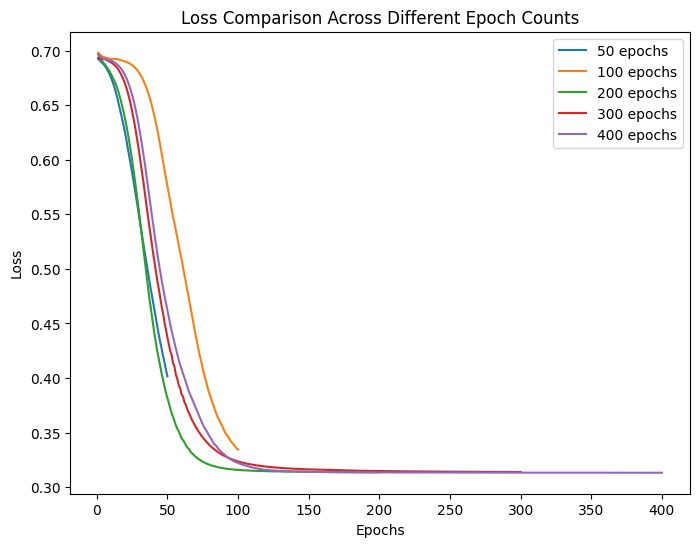

In [ ]:
# Plot loss curves for different epoch counts
plt.figure(figsize=(8, 6))
for e, losses in loss_curves.items():
    plt.plot(range(1, len(losses) + 1), losses, label=f"{e} epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Comparison Across Different Epoch Counts")
plt.legend()
plt.show()

**Interpretation**
- Above plot shows the model trained for different number of epochs based on color.
- All curves start around 0.7  loss, meaning the models initial predictions are close to random and the loss drops sharply
- For 50-150 erpochs, the loss continues to decrease but at a slow rate.
- After 200-250 epochs, all the curves flatten at a loss around 0.32.


Training final model with optimal 400 epochs...


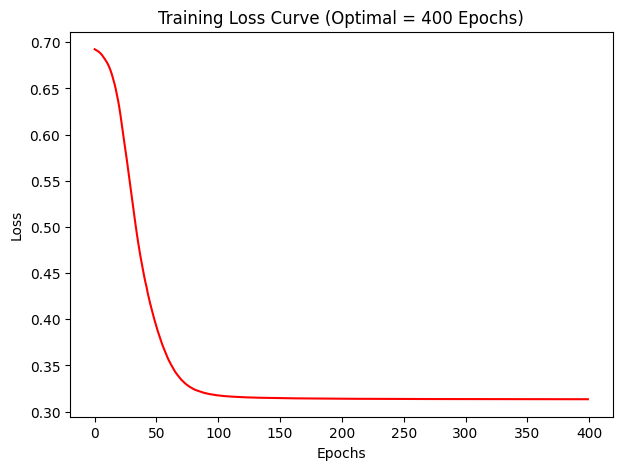

In [131]:
print(f"\nTraining final model with optimal {optimal_epochs} epochs...")
model = SimpleGNN(input_dim=4, hidden_dim=8, output_dim=2)
optimal_losses = train_model(model, optimal_epochs, lr=0.01)

plt.figure(figsize=(7, 5))
plt.plot(range(optimal_epochs), optimal_losses, color='red')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title(f"Training Loss Curve (Optimal = {optimal_epochs} Epochs)")
plt.show()

Above plot shows the train loss with optimal number of epochs which is 400 in this case. 